# **TP7 - Corresponding Analysis (CA)**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Lecturer: Dr. HAS Sothea** <br>
**Ms. UANN Sreyvi**

-------

**Objective**: Qualitative columns are often ignored in predictive models or analysis. It is important to notice that qualitative variables are as important as the quantitative ones when it comes to building predictive models or analyzing their connection within the dataset. In this TP, we will focus on identifying the associations between two qualitative variables.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP7_CA.ipynb](https://hassothea.github.io/EDA_ITC/TPs/TP7_CA.ipynb)**.

-------

## 1. Data loading and Preprocessing

`Titanic` dataset contains information on the passengers aboard the RMS Titanic, which sank in 1912. It includes details like age, gender, class, and survival status.

**A.** Import the `Titanic` dataset from kaggle using: [Titanic dataset](https://www.kaggle.com/datasets/surendhan/titanic-dataset).

- How many quantitative and qualitative variables are there in this dataset?
- Convert each column into its correct data type.

**Name: Phoeurn Kimhor**
**Group: I5-AMS-B**

In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("surendhan/titanic-dataset")

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [83]:
# Import data
import pandas as pd
df = pd.read_csv(path + "/titanic.csv")
print(df.shape)
display(df.head())

(418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [84]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [85]:
df = df.astype({'Survived' : 'object', 'Pclass' : 'object', 'SibSp' : 'object', 'Parch' : 'object'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    object 
 1   Pclass    418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    object 
 5   Parch     418 non-null    object 
 6   Fare      417 non-null    float64
 7   Cabin     91 non-null     object 
 8   Embarked  418 non-null    object 
dtypes: float64(2), object(7)
memory usage: 29.5+ KB


**B.** Are there any missing values? If so,

- Study the impact of missing value removal on the quantitative variables.
- Study the impact of missing value removal on the qualitative variables.
- Conclude the dynamic of the missing values and handle them.
- Remove redundant observations if there is any.

In [86]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Cabin,327
Embarked,0


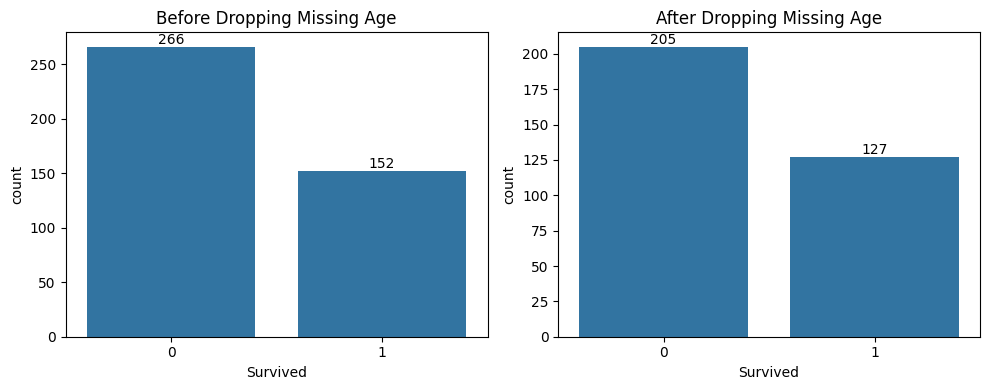

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

dropna_age = df.dropna(subset=['Age'])

plt.figure(figsize=(10, 4))

ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Survived', ax=ax1)
ax1.set_title('Before Dropping Missing Age')
for c in ax1.containers:
    ax1.bar_label(c)

ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=dropna_age, x='Survived', ax=ax2)
ax2.set_title('After Dropping Missing Age')
for c in ax2.containers:
    ax2.bar_label(c)

plt.tight_layout()
plt.show()

> dropping missing age does not have much effect on the target.

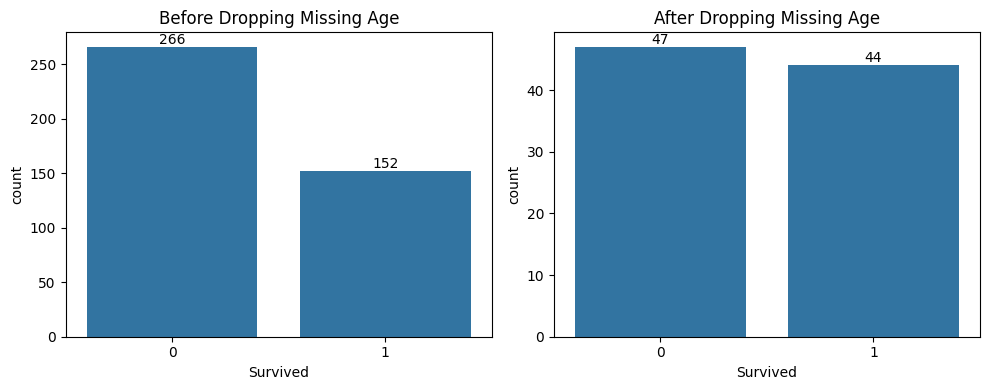

In [88]:
dropna_cabin = df.dropna(subset=['Cabin'])

plt.figure(figsize=(10, 4))

ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Survived', ax=ax1)
ax1.set_title('Before Dropping Missing Age')
for c in ax1.containers:
    ax1.bar_label(c)

ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=dropna_cabin, x='Survived', ax=ax2)
ax2.set_title('After Dropping Missing Age')
for c in ax2.containers:
    ax2.bar_label(c)

plt.tight_layout()
plt.show()

In [89]:
print(f"Unique values in Cabin: {df['Cabin'].nunique()}")
print(f"Total Dataset: {df.shape[0]}")
print(f"Missing Cabin: {df['Cabin'].isna().sum()} = {round(df['Cabin'].isna().sum() / df.shape[0] * 100, 2)}% of total data")

Unique values in Cabin: 76
Total Dataset: 418
Missing Cabin: 327 = 78.23% of total data


> dropping rows with missing cabin change the proportion of the target a lot. So it's best not to drop row wise. Instead, since about 78% of it are missing, it is safe to drop column wise.

In [90]:
df = df.dropna(subset=['Age'])
df = df.drop(columns=['Cabin'])
print(df.shape)

(332, 8)


In [91]:
print(f"Count of Redundant Values: {df.duplicated().sum()}")

Count of Redundant Values: 10


## 2. $\chi^2$-test and CA

The chi-square test is a statistical method used to determine if there is a significant association between two categorical variables. It tests the following hypotheses:
$$\begin{cases}
H_0:\text{ There is no association between the two variables (they are independent).}\\
H_1:\text{ There is an association between the two variables (they are not independent).}
\end{cases}$$
Under null hypothesis $H_0$, $\chi^2$-statistic defined by $\chi^2=\sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}\sim\chi^2((r-1)(c-1))$ where

- $r,c$: the number of categories of the 1st and 2nd variable respectively.
- $O_{ij}$: the observed frequency of $i$-th and $j$-th category of the 1st and the 2nd variable.
- $E_{ij}$: the expected/theoretical frequency of $i$-th and $j$-th category of the 1st and the 2nd variable.

**A. $\chi^2$-test for Pclass vs Survived.**

- Visualize the relationship between the two variables.
- Compute the $\chi^2$ statistics of the pair `Pclass` and `Survived` variable.
- Deduce the p-value of $\chi^2$-test of the two variables.
- Can we reject the null hypothesis $H_0$ of the two variables being independent at $95\%$ confidence level?
- Recall the assumptions of $\chi^2$-test. Is the result above reliable?

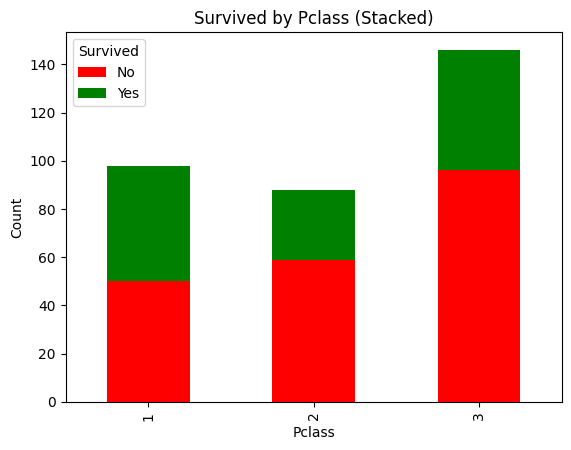

In [92]:
pivot = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, color=['red', 'green'])
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.title('Survived by Pclass (Stacked)')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

> from this plot, it indicates there are differences so there is a relationship.

In [93]:
import numpy as np
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Pclass'], df['Survived'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 6.811934789344246
Degrees of freedom: 2
p-value: 0.033174711514497884
Expected frequencies:
 [[60.51204819 37.48795181]
 [54.3373494  33.6626506 ]
 [90.15060241 55.84939759]]


with p-value < 0.05, we can reject H0. So there is a relationship between `Pclass` and `Survived`

**B. Pclass vs Embarked:**

- Perform $\chi^2$-test on this pair of variables.
- Perform CA on this pair of variables.
- Create `symmetric biplot` of the resulting CA.
- Interpret the result.

In [94]:
contingency = pd.crosstab(df['Pclass'], df['Embarked'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 78.94158988961557
Degrees of freedom: 4
p-value: 2.918725780820331e-16
Expected frequencies:
 [[ 24.20481928   6.4939759   67.30120482]
 [ 21.73493976   5.8313253   60.43373494]
 [ 36.06024096   9.6746988  100.26506024]]


p-value < 0.05, there is a relationship.

In [95]:
import prince

ca = prince.CA(n_components=2, n_iter=3, random_state=2)
ca = ca.fit(contingency)

rows = ca.row_coordinates(contingency)
cols = ca.column_coordinates(contingency)

print("Row coordinates (Pclass):\n", rows)
print("Column coordinates (Embarked):\n", cols)


Row coordinates (Pclass):
                0         1
Pclass                    
1       0.714995  0.000364
2      -0.300528  0.235920
3      -0.298788 -0.142443
Column coordinates (Embarked):
                  0         1
Embarked                    
C         0.796686 -0.044660
Q        -0.546658 -0.548238
S        -0.233780  0.068962


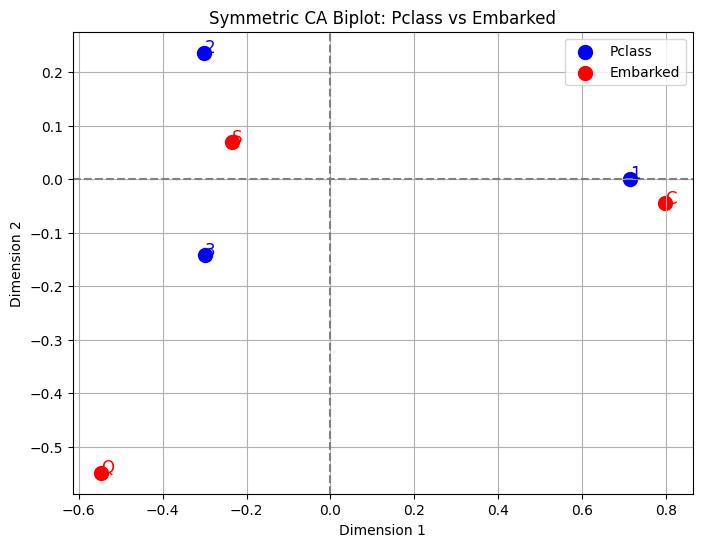

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(rows[0], rows[1], color='blue', label='Pclass', s=100)
plt.scatter(cols[0], cols[1], color='red', label='Embarked', s=100)

for i, txt in enumerate(rows.index):
    plt.annotate(txt, (rows.iloc[i,0], rows.iloc[i,1]), color='blue', fontsize=12)

for i, txt in enumerate(cols.index):
    plt.annotate(txt, (cols.iloc[i,0], cols.iloc[i,1]), color='red', fontsize=12)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Symmetric CA Biplot: Pclass vs Embarked')
plt.legend()
plt.grid(True)
plt.show()

- Pclass 1 passengers mainly embarked from C.
- Pclass 3 passengers mainly embarked from Q.
- Pclass 2 passengers mainly embarked from S.

## 3. Eye and Hair color

Study the connection between eye and hair colors from the `Eye & Hair Color` dataset available in kaggle as [Hair Eye Color](https://www.kaggle.com/datasets/jasleensondhi/hair-eye-color).

In [97]:
import kagglehub

path = kagglehub.dataset_download("jasleensondhi/hair-eye-color")

df = pd.read_csv(path + "/HairEyeColor.csv").drop(columns=['Unnamed: 0'])
print(df.shape)
display(df.head())

Using Colab cache for faster access to the 'hair-eye-color' dataset.
(32, 4)


,Hair,Eye,Sex,Freq
0,Black,Brown,Male,32
1,Brown,Brown,Male,53
2,Red,Brown,Male,10
3,Blond,Brown,Male,3
4,Black,Blue,Male,11


In [98]:
contingency = df.pivot_table(
    index='Hair',
    columns='Eye',
    values='Freq',
    aggfunc='sum',
    fill_value=0
)

contingency

Eye,Blue,Brown,Green,Hazel
Hair,,,,
Black,20,68,5,15
Blond,94,7,16,10
Brown,84,119,29,54
Red,17,26,14,14


In [99]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 138.28984162600827
Degrees of freedom: 9
p-value: 2.3252867870988044e-25
Expected frequencies:
 [[ 39.22297297  40.13513514  11.67567568  16.96621622]
 [ 46.12331081  47.19594595  13.72972973  19.95101351]
 [103.86824324 106.28378378  30.91891892  44.92905405]
 [ 25.78547297  26.38513514   7.67567568  11.15371622]]


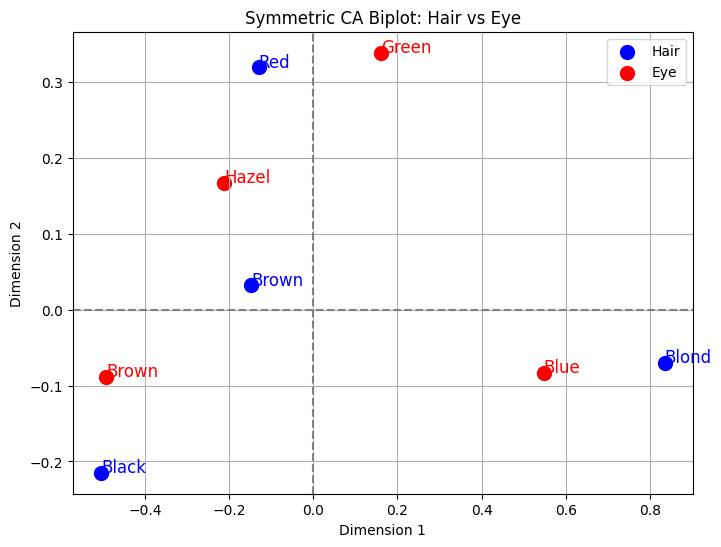

In [100]:
ca = prince.CA(n_components=2, n_iter=3, random_state=2)
ca = ca.fit(contingency)

rows = ca.row_coordinates(contingency)
cols = ca.column_coordinates(contingency)

plt.figure(figsize=(8,6))
plt.scatter(rows[0], rows[1], color='blue', label='Hair', s=100)
plt.scatter(cols[0], cols[1], color='red', label='Eye', s=100)

for i, txt in enumerate(rows.index):
    plt.annotate(txt, (rows.iloc[i,0], rows.iloc[i,1]), color='blue', fontsize=12)

for i, txt in enumerate(cols.index):
    plt.annotate(txt, (cols.iloc[i,0], cols.iloc[i,1]), color='red', fontsize=12)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Symmetric CA Biplot: Hair vs Eye')
plt.legend()
plt.grid(True)
plt.show()

* Strong associations:

  * `Black` hair & `Brown` eyes
  * `Blond` hair & `Blue` eyes

* Moderate associations:

  * `Brown` hair & `Hazel` eyes
  * `Red` hair & `Hazel` eyes

* Distinct / rare categories:

  * `Green` eyes (less frequent, weakly associated with any hair color)

## 4. Countries and languages

Reproduce results of the association between countries and primary language spoken within those countries conducted [here](https://pmc.ncbi.nlm.nih.gov/articles/PMC3718710/). The contingency table of country of residence and primary language spoken is given below:

| Country\ Language  | English | French | Spanish | German | Italian | Total |
|:-------------------|:-------:|:------:|:-------:|:------:|:-------:|:-----:|
| Canada | 688 | 280 | 10 | 11 | 11 | 1000 |
| USA | 730 | 31 | 190 | 8 | 41 | 1000 |
| England | 798 | 74 | 38 | 31 | 59 | 1000 |
| Italy | 17 | 13 | 11 | 15 | 944 | 1000 |
| Switzerland | 15 | 222 | 20 | 648 | 95 | 1000 |
| Total | 2248 | 620 | 269 | 713 | 1150 | 5000 |

In [101]:
data = {
    'Country': ['Canada', 'USA', 'England', 'Italy', 'Switzerland'],
    'English': [688, 730, 798, 17, 15],
    'French': [280, 31, 74, 13, 222],
    'Spanish': [10, 190, 38, 11, 20],
    'German': [11, 8, 31, 15, 648],
    'Italian': [11, 41, 59, 944, 95]
}
df = pd.DataFrame(data)
df = df.set_index('Country')
df

,English,French,Spanish,German,Italian
Country,,,,,
Canada,688,280,10,11,11
USA,730,31,190,8,41
England,798,74,38,31,59
Italy,17,13,11,15,944
Switzerland,15,222,20,648,95


In [102]:
chi2, p, dof, expected = chi2_contingency(df)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 7338.935598897499
Degrees of freedom: 16
p-value: 0.0
Expected frequencies:
 [[449.6 124.   53.8 142.6 230. ]
 [449.6 124.   53.8 142.6 230. ]
 [449.6 124.   53.8 142.6 230. ]
 [449.6 124.   53.8 142.6 230. ]
 [449.6 124.   53.8 142.6 230. ]]


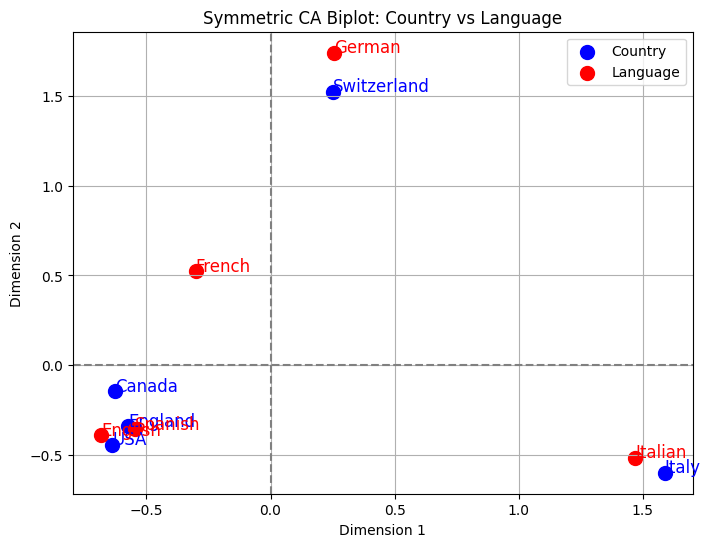

In [103]:
ca = prince.CA(n_components=2, n_iter=3, random_state=2)
ca = ca.fit(df)

rows = ca.row_coordinates(df)
cols = ca.column_coordinates(df)

plt.figure(figsize=(8,6))
plt.scatter(rows[0], rows[1], color='blue', label='Country', s=100)
plt.scatter(cols[0], cols[1], color='red', label='Language', s=100)

for i, txt in enumerate(rows.index):
    plt.annotate(txt, (rows.iloc[i,0], rows.iloc[i,1]), color='blue', fontsize=12)

for i, txt in enumerate(cols.index):
    plt.annotate(txt, (cols.iloc[i,0], cols.iloc[i,1]), color='red', fontsize=12)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Symmetric CA Biplot: Country vs Language')
plt.legend()
plt.grid(True)
plt.show()

* `Italian` and `Italy` -> very strong association
* `German` and `Switzerland` -> strong association
* `English` and `USA` -> strong association
* `Spanish` and `USA` -> strong association
* `English` and `Spanish` is closer to `Canada` compared to `French` -> English and Spanish are more common in Canada than French


# Further Readings

- [Correspondence Analysis, Hervé Abdi & Michel Béra](https://cedric.cnam.fr/fichiers/art_3066.pdf)
- [Correspondence analysis is a useful tool to uncover the relationships among categorical variables](https://pmc.ncbi.nlm.nih.gov/articles/PMC3718710/)
- [The Use of Correspondence Analysis in the Exploration of Health Survey Data](www.fbbva.es/wp-content/uploads/2017/05/dat/DT_2002_05.pdf)
- [Correspondence Analysis](https://link.springer.com/referenceworkentry/10.1007/978-1-4939-7131-2_140)